Mount data from Google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Code cell to delete folders npy

In [ ]:
import shutil

folder_to_delete1 = "/content/demo_frames"
folder_to_delete2 = "/content/AI model"
# Xóa cả folder và tất cả file bên trong
shutil.rmtree(folder_to_delete2)

FileNotFoundError: [Errno 2] No such file or directory: '/content/AI model'

Libraries and Path

In [ ]:
# =====================
# 📦 PHASE 0: IMPORT + PATH SETUP
# =====================

# --- Thư viện cơ bản ---
import os
import cv2
import random
import numpy as np
from tqdm import tqdm
from PIL import Image
import pandas as pd
from typing import Optional

# --- PyTorch core ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms

# --- Visualization / Debug ---
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# =====================
# Đường dẫn tài nguyên (Google Drive)
# Xin thầy hãy đảm bảo đường dẫn ạ
# =====================

violence_folder_path  = "/content/drive/MyDrive/Colab Notebooks/Real Life Violence Dataset/Violence processed"
non_violence_folder_path = "/content/drive/MyDrive/Colab Notebooks/Real Life Violence Dataset/Non Violence processed"

# CSV chứa metadata mô tả các thư mục video
folder_csv_link = "/content/drive/MyDrive/Colab Notebooks/summary2.csv"

# Thư mục tạm để chứa frame sau khi tách
demo_frames_folder = "/content/demo_frames"

# Nếu chưa tồn tại thì tạo luôn
os.makedirs(demo_frames_folder, exist_ok=True)

print("✅ Libraries loaded & paths set up successfully!")

✅ Libraries loaded & paths set up successfully!


# From video to frames

In [ ]:
def resize(frame, size=(224, 224)):
    """
    Input:
        frame (ndarray): Ảnh gốc đọc từ video (BGR)
    Output:
        resized frame (ndarray): Ảnh 224x224
    """
    return cv2.resize(frame, size)

In [ ]:
def normalize(frame):
    """
    Input:
        frame (ndarray): Ảnh sau khi resize
    Output:
        normalized frame (ndarray): Ảnh scale 0-1, RGB order
    """
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # chuyển từ BGR → RGB
    frame = frame.astype(np.float32) / 255.0        # chuẩn hóa
    return frame

In [ ]:
def frame_conversion(video_path, output_root="/content/demo_frames"):
    """
    Convert video clips into frames, resize and normalize them, then save to a directory.

    Args:
        video_path (str): Path to a directory containing multiple .mp4 video clips.
                          Each video clip represents a segment of the same source video.
        output_root (str): Root directory where frames will be saved. Defaults to "/content/demo_frames".

    Returns:
        str: Path to the root directory where frames are saved.
    """

    # Check if the video directory exists
    if not os.path.exists(video_path):
        print(f"[!] Folder not found: {video_path}")
        return None

    # Get the parent folder name from the video path
    parent_folder = os.path.basename(video_path.rstrip("/"))
    save_root = os.path.join(output_root, parent_folder)
    os.makedirs(save_root, exist_ok=True)

    # List all .mp4 video files in the provided directory
    video_files = [
        os.path.join(video_path, f)
        for f in os.listdir(video_path)
        if f.lower().endswith(".mp4")
    ]

    if not video_files:
        print(f"[!] No video files found in {video_path}")
        return save_root

    # Process each video clip
    for clip_path in video_files:
        clip_name = os.path.splitext(os.path.basename(clip_path))[0]

        # Create a directory for saving frames for each video
        clip_save_folder = os.path.join(save_root, clip_name)
        os.makedirs(clip_save_folder, exist_ok=True)

        cap = cv2.VideoCapture(clip_path)

        if not cap.isOpened():
            print(f"[!] Cannot open video: {clip_name}")
            continue

        frame_idx = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # Resize and normalize the frame
            frame = resize(frame)      # Assuming resize() is defined elsewhere
            frame = normalize(frame)   #

            # Construct the filename and save the frame
            save_name = f"{clip_name}_f{frame_idx:05d}.jpg"
            save_path = os.path.join(clip_save_folder, save_name)
            cv2.imwrite(save_path, (frame * 255).astype('uint8'))
            frame_idx += 1

        cap.release()

    return save_root

Example Usage

In [ ]:
link_demo = os.path.join(violence_folder_path, "Folder 2")
frame_conversion(link_demo)

[!] Folder not found: /content/drive/MyDrive/Colab Notebooks/Real Life Violence Dataset/Violence processed/Folder 2


# From frames to vector

Define ResNet50 to convert frames to feature

In [ ]:
def load_resnet50_model(device="cuda"):
    model = models.resnet50(pretrained=True)
    model = nn.Sequential(*list(model.children())[:-1])
    model.eval()
    model.to(device)
    return model

device = "cuda"
resnet50_model = load_resnet50_model(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


Convert one frame to vector

In [ ]:
def frame_to_vector(frame_path, model, device="cuda"):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    img = Image.open(frame_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feature = model(tensor).view(-1).cpu().numpy()
    return feature

Convert the entire folder frame to folder vector

Delete jpg files

In [ ]:
def cleanup_frames(folder_path):
    removed = 0
    for f in os.listdir(folder_path):
        if f.lower().endswith(".jpg"):
            os.remove(os.path.join(folder_path, f))
            removed += 1

In [ ]:
def folder_to_vectors(folder_path, model, device="cuda"):
    """
    Chuyển toàn bộ frame (.jpg) trong các sub_folder thành vector (.npy)
    Mỗi sub_folder tương ứng 1 video (đã tách frame sẵn)
    Đặt tên file theo format: <video_name>_f<idx:04d>.npy
    Sau khi hoàn tất, xóa toàn bộ file .jpg để tiết kiệm dung lượng
    """

    # Duyệt qua tất cả sub_folder trong folder_path
    subfolders = [
        os.path.join(folder_path, d)
        for d in os.listdir(folder_path)
        if os.path.isdir(os.path.join(folder_path, d))
    ]

    if not subfolders:
        print(f"[!] No subfolders found in {folder_path}")
        return

    for subfolder in subfolders:
        video_name = os.path.basename(subfolder)
        frame_files = sorted([
            f for f in os.listdir(subfolder)
            if f.lower().endswith(".jpg")
        ])

        if not frame_files:
            print(f"[!] No frames found in {subfolder}")
            continue

        print(f"[▶️] Processing video: {video_name} ({len(frame_files)} frames)")

        for idx, frame_file in enumerate(frame_files):
            frame_path = os.path.join(subfolder, frame_file)
            vec = frame_to_vector(frame_path, model, device)

            # Đảm bảo tensor nằm trên CPU trước khi lưu
            if hasattr(vec, "detach"):
                vec = vec.detach().cpu().numpy()

            save_name = f"{video_name}_f{idx:04d}.npy"
            save_path = os.path.join(subfolder, save_name)
            np.save(save_path, vec)

        print(f"[💾] Saved {len(frame_files)} vectors for {video_name}")

        # Cleanup frames sau khi xong
        cleanup_frames(subfolder)

    print("[✅] All videos processed successfully!")

Usage example

In [ ]:
folder_path = "/content/demo_frames/Folder 2"
folder_to_vectors(folder_path, resnet50_model, device)
cleanup_frames(folder_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/demo_frames/Folder 2'

# Loop all folders to have real npy files: Real implementation

In [ ]:
# ======================
# Cấu hình đường dẫn
# ======================
violence_root = violence_folder_path
nonviolence_root = non_violence_folder_path

# Thư mục tạm để lưu frame (Colab session)
# demo_frames_root = "/content/demo_frames"

In [ ]:
def process_all_videos(violence_root, non_violence_root, model, device="cuda"):
    """
    Pipeline tổng:
    1️⃣ Video (.mp4) → Frames (.jpg)
    2️⃣ Frames (.jpg) → Vector (.npy)
    3️⃣ Xóa .jpg sau khi xong (gộp trong folder_to_vectors)

    Chỉ hiển thị 2 thanh tiến độ chính:
        - Violence processed
        - NonViolence processed
    """

    folders = {
        "Violence": violence_root,
        "NonViolence": non_violence_root
    }

    for group_name, group_path in folders.items():
        print(f"\n[🔥] Processing group: {group_name}")

        # Tất cả các subfolder (mỗi subfolder chứa nhiều video)
        subfolders = [
            os.path.join(group_path, sf)
            for sf in os.listdir(group_path)
            if os.path.isdir(os.path.join(group_path, sf))
        ]

        if not subfolders:
            print(f"[!] No subfolders found in {group_path}")
            continue

        # Thanh tiến độ lớn (1 cho mỗi nhóm)
        for subfolder in tqdm(subfolders, desc=f"{group_name} processed", unit="folder"):

            # 1️⃣ Video → Frames
            frame_conversion(subfolder)  # ✅ Gọi bằng folder_path, không phải video_path

            # Xác định folder chứa frame sau khi extract
            parent_name = os.path.basename(subfolder)
            frame_folder = os.path.join("/content/demo_frames", parent_name)

            # 2️⃣ Frames → Vectors (.npy)
            folder_to_vectors(frame_folder, model=model, device=device)

        print(f"[✅] Finished group: {group_name}")

    print("\n🎉 All videos processed successfully!")

Implementation final

In [ ]:
process_all_videos(violence_folder_path, non_violence_folder_path, model=resnet50_model, device="cuda")


[🔥] Processing group: Violence


Violence processed:   0%|          | 0/244 [00:00<?, ?folder/s]

[▶️] Processing video: V_820 (144 frames)
[💾] Saved 144 vectors for V_820
[▶️] Processing video: V_827 (144 frames)
[💾] Saved 144 vectors for V_827
[▶️] Processing video: V_826 (126 frames)
[💾] Saved 126 vectors for V_826
[▶️] Processing video: V_825 (183 frames)


Violence processed:   0%|          | 1/244 [00:09<39:36,  9.78s/folder]

[💾] Saved 183 vectors for V_825
[✅] All videos processed successfully!
[▶️] Processing video: V_31 (62 frames)


...

[💾] Saved 153 vectors for V_93
[✅] All videos processed successfully!
[▶️] Processing video: V_621 (185 frames)
[💾] Saved 185 vectors for V_621
[▶️] Processing video: V_619 (185 frames)
[💾] Saved 185 vectors for V_619
[▶️] Processing video: V_622 (185 frames)
[💾] Saved 185 vectors for V_622
[▶️] Processing video: V_620 (185 frames)


Violence processed:  36%|███▌      | 87/244 [21:56<50:36, 19.34s/folder]

[💾] Saved 185 vectors for V_620
[✅] All videos processed successfully!
[▶️] Processing video: V_706 (125 frames)
[💾] Saved 125 vectors for V_706
[▶️] Processing video: V_704 (125 frames)
[💾] Saved 125 vectors for V_704
[▶️] Processing video: V_703 (125 frames)
[💾] Saved 125 vectors for V_703
[▶️] Processing video: V_708 (125 frames)
[💾] Saved 125 vectors for V_708
[▶️] Processing video: V_709 (125 frames)
[💾] Saved 125 vectors for V_709
[▶️] Processing video: V_705 (125 frames)
[💾] Saved 125 vectors for V_705
[▶️] Processing video: V_702 (125 frames)
[💾] Saved 125 vectors for V_702
[▶️] Processing video: V_707 (125 frames)
[💾] Saved 125 vectors for V_707
[▶️] Processing video: V_691 (125 frames)
[💾] Saved 125 vectors for V_691
[▶️] Processing video: V_700 (125 frames)
[💾] Saved 125 vectors for V_700
[▶️] Processing video: V_693 (125 frames)
[💾] Saved 125 vectors for V_693
[▶️] Processing video: V_701 (125 frames)
[💾] Saved 125 vectors for V_701
[▶️] Processing video: V_692 (125 frames)

Violence processed:  36%|███▌      | 88/244 [22:20<53:27, 20.56s/folder]

[💾] Saved 125 vectors for V_692
[✅] All videos processed successfully!
[▶️] Processing video: V_699 (125 frames)
[💾] Saved 125 vectors for V_699
[▶️] Processing video: V_658 (125 frames)
[💾] Saved 125 vectors for V_658
[▶️] Processing video: V_684 (125 frames)
[💾] Saved 125 vectors for V_684
[▶️] Processing video: V_685 (125 frames)
[💾] Saved 125 vectors for V_685
[▶️] Processing video: V_716 (125 frames)
[💾] Saved 125 vectors for V_716
[▶️] Processing video: V_710 (125 frames)
[💾] Saved 125 vectors for V_710
[▶️] Processing video: V_713 (125 frames)
[💾] Saved 125 vectors for V_713
[▶️] Processing video: V_719 (125 frames)
[💾] Saved 125 vectors for V_719
[▶️] Processing video: V_718 (125 frames)
[💾] Saved 125 vectors for V_718
[▶️] Processing video: V_712 (125 frames)
[💾] Saved 125 vectors for V_712
[▶️] Processing video: V_686 (125 frames)
[💾] Saved 125 vectors for V_686
[▶️] Processing video: V_682 (125 frames)
[💾] Saved 125 vectors for V_682
[▶️] Processing video: V_715 (125 frames)

# Folder Division

In [ ]:
class Folder:
    def __init__(self, link: str, train_val_test: Optional[str] = None):
        """
        Đại diện cho 1 folder chứa dữ liệu (vd: npy vectors của video)

        Args:
            link (str): đường dẫn thư mục
            train_val_test (str, optional): tập dữ liệu (train / val / test)
        """
        if not os.path.exists(link):
            raise FileNotFoundError(f"[!] Folder not found: {link}")

        self.link = link
        self.name = os.path.basename(link.rstrip("/"))
        self.train_val_test = train_val_test or None

        # Đếm số lượng subfolder & npy
        self.num_sub_folder = self._count_subfolders()
        self.num_npy_file = self._count_npy_files()

        # Xác định label tự động
        self.label = self.get_label()

    # --------------------------
    # 🧩 Các hàm tiện ích cơ bản
    # --------------------------

    def _count_subfolders(self) -> int:
        """Đếm số lượng thư mục con"""
        return len([
            d for d in os.listdir(self.link)
            if os.path.isdir(os.path.join(self.link, d))
        ])

    def _count_npy_files(self) -> int:
        """Đếm tổng số file .npy trong tất cả subfolders"""
        total = 0
        for root, _, files in os.walk(self.link):
            total += len([f for f in files if f.lower().endswith(".npy")])
        return total

    def get_label(self) -> str:
        """
        Xác định label dựa trên tên sub_folder đầu tiên.
        Ví dụ sub_folder: 'V_4_ Violence something' → 'Violence'
        """
        subfolders = [
            d for d in os.listdir(self.link)
            if os.path.isdir(os.path.join(self.link, d))
        ]

        if not subfolders:
            return "Unknown"

        first_sub_folder_name = subfolders[0]
        parts = first_sub_folder_name.split(" ")

        try:
            if parts[-1][0] == "N":
                return "NonViolence"
            elif parts[-1][0] == "V":
                return "Violence"
        except Exception:
            pass

        return "Unknown"

    def refresh(self):
        """Cập nhật lại số lượng subfolder và file npy"""
        self.num_sub_folder = self._count_subfolders()
        self.num_npy_file = self._count_npy_files()
        self.label = self.get_label()

    def summary(self):
        """In thông tin tóm tắt về folder"""
        print(f"📁 Folder: {self.name}")
        print(f"   ├─ Path: {self.link}")
        print(f"   ├─ Label: {self.label}")
        print(f"   ├─ Subfolders: {self.num_sub_folder}")
        print(f"   ├─ .npy files: {self.num_npy_file}")
        print(f"   └─ Dataset split: {self.train_val_test}")

    def list_subfolders(self):
        """Trả về danh sách đường dẫn subfolder"""
        return [
            os.path.join(self.link, d)
            for d in os.listdir(self.link)
            if os.path.isdir(os.path.join(self.link, d))
        ]

    def set_split(self, split: str):
        """Gán loại tập dữ liệu (train / val / test)"""
        if split not in ["train", "val", "test"]:
            raise ValueError("split phải là 'train', 'val', hoặc 'test'")
        self.train_val_test = split

    def get_parent_folder(self):
        """
        Trả về đường dẫn folder cha chứa folder này.
        """
        return os.path.dirname(self.link)

    def get_split(self):
      return self.train_val_test

    def __repr__(self):
        return (
            f"<Folder name='{self.name}' "
            f"label='{self.label}' sub={self.num_sub_folder} "
            f"npy={self.num_npy_file} split={self.train_val_test}>"
        )

Example usage

In [ ]:
# Khởi tạo
f = Folder("/content/demo_frames/Soccer competition", train_val_test="train")

# In thông tin tóm tắt
f.summary()

# Lấy danh sách các subfolder (mỗi video)
subs = f.list_subfolders()
print(subs[:3])

# Cập nhật lại thống kê (sau khi thêm file mới)
f.refresh()

# Đổi loại dataset
f.set_split("test") # Hàm này hoạt động ko đúng dự định bro ơi

# In thông tin tóm tắt
f.summary()

# Xem nhanh
print(f)

FileNotFoundError: [!] Folder not found: /content/demo_frames/Soccer competition

Create lst containing object Folder

In [ ]:
# --- 1️⃣: Tạo list các object Folder ---
# Giả sử bạn đã có class Folder (với các attribute như name, label, num_sub_folder, num_npy_file,...)
# Thì ta sẽ duyệt toàn bộ thư mục trong demo_frames và khởi tạo object cho mỗi folder.

root_folder = "/content/demo_frames"

lst_folders = []
for folder_name in sorted(os.listdir(root_folder)):
    folder_path = os.path.join(root_folder, folder_name)
    if os.path.isdir(folder_path):
        f = Folder(folder_path)  # khởi tạo object Folder
        lst_folders.append(f)
        print(f"[📁] Created Folder object for: {folder_name}")

print(f"\n[✅] Total {len(lst_folders)} Folder objects created.")

[📁] Created Folder object for: 0_1 man escape
[📁] Created Folder object for: 0_A girl is muckbang
[📁] Created Folder object for: 100_2 wm fight on crossing line
[📁] Created Folder object for: 101_2 wm fight ouside a house, 1 fat and wear yellow dress
[📁] Created Folder object for: 102_2 wm fight slow motion
[📁] Created Folder object for: 103_2 wm fight under the stairs
[📁] Created Folder object for: 104_2 wm punch in road, 1 red hair, 1 red shirt
[📁] Created Folder object for: 105_2 wm wear shorts fight in road, 1 have yellow shirt
[📁] Created Folder object for: 106_2 women are fighting
[📁] Created Folder object for: 107_2 women hair pulling in middle road, 1 have lemon shirt
[📁] Created Folder object for: 108_2 women in black fighting
[📁] Created Folder object for: 109_2 women slap and pull each other's hair
[📁] Created Folder object for: 10_1 man in black and 1 man with a stick
[📁] Created Folder object for: 10_Billard green
[📁] Created Folder object for: 110_2 women wrestling
[📁] Cr

Create dataframe of metadata: folder_name, label, num_sub_folder, total_num_npy_file

In [ ]:
def create_metadata_from_objects(lst_folders):
    """
    Tạo DataFrame metadata từ list các object Folder.
    Các cột: folder_name, label, num_sub_folder, total_num_npy_file
    """
    records = []

    for f in lst_folders:
        # đảm bảo các attribute tồn tại
        records.append({
            "folder_name": f.name,
            "label": f.label,
            "num_sub_folder": getattr(f, "num_sub_folder", 0),
            "total_num_npy_file": getattr(f, "num_npy_file", 0),  # hoặc .total_num_npy_file tùy bạn
        })

    df = pd.DataFrame(records)
    return df


# --- ví dụ chạy ---
df = create_metadata_from_objects(lst_folders)
df.head(20)

,folder_name,label,num_sub_folder,total_num_npy_file
0,0_1 man escape,Violence,1,78
1,0_A girl is muckbang,Unknown,0,0
2,100_2 wm fight on crossing line,Violence,2,270
3,"101_2 wm fight ouside a house, 1 fat and wear ...",Violence,1,177
4,102_2 wm fight slow motion,Violence,3,522
5,103_2 wm fight under the stairs,Violence,5,759
6,"104_2 wm punch in road, 1 red hair, 1 red shirt",Violence,6,843
7,"105_2 wm wear shorts fight in road, 1 have yel...",Violence,3,423
8,106_2 women are fighting,Violence,2,321
9,"107_2 women hair pulling in middle road, 1 hav...",Violence,5,572


Greedy split according to ratio through greedy method + merge vào DataFrame

In [ ]:
def greedy_split_by_ratio(df, ratios=(0.7, 0.15, 0.15), value_col="total_num_npy_file"):
    splits = {}
    split_labels = ["train", "val", "test"]

    final_assignments = {}

    for label in df["label"].unique():
        sub_df = df[df["label"] == label].sort_values(value_col, ascending=False)
        total = sub_df[value_col].sum()
        targets = {
            "train": total * ratios[0],
            "val": total * ratios[1],
            "test": total * ratios[2]
        }
        sums = {k: 0 for k in split_labels}
        splits[label] = {k: [] for k in split_labels}

        print(f"\n[⚖️] Splitting label '{label}' — total npy = {total}")
        for _, row in sub_df.iterrows():
            deficits = {k: targets[k] - sums[k] for k in split_labels}
            chosen = max(deficits, key=deficits.get)
            splits[label][chosen].append(row["folder_name"])
            sums[chosen] += row[value_col]
            final_assignments[row["folder_name"]] = chosen
            print(f"   → {row['folder_name']:<40} → {chosen}")

        # Summary
        print(f"[📊] {label} summary:")
        for k in split_labels:
            pct = sums[k] / total * 100 if total else 0
            print(f"   {k:<5}: {sums[k]:<8} ({pct:.1f}%)")

    return final_assignments


# --- chạy ---
split_dict = greedy_split_by_ratio(df)
df["train_val_test"] = df["folder_name"].map(split_dict)

print("\n[✅] Final DataFrame with split column:")
display(df.head(10))

# Summary: tổng số npy per split per label
summary = (
    df.groupby(["label", "train_val_test"])["total_num_npy_file"]
      .sum()
      .unstack(fill_value=0)
)
summary["Total"] = summary.sum(axis=1)
summary["Train%"] = (summary["train"] / summary["Total"] * 100).round(1)
summary["Val%"] = (summary["val"] / summary["Total"] * 100).round(1)
summary["Test%"] = (summary["test"] / summary["Total"] * 100).round(1)

print("\n[📈] Split summary by label:")
display(summary)
summary.to_csv("/content/Summary.csv")


[⚖️] Splitting label 'Violence' — total npy = 159482
   → 223_Sport video mix                      → train
   → 238_Video mix                            → train
   → 162_Conflict between two hockey players  → train
   → 225_Street fighting                      → train
   → 239_Video mix men                        → train
   → 157_Conflict between 2 rugby teams, 1 blue and 1 white → train
   → 151_Boxing video mix                     → train
   → 161_Conflict between 2 rugbyy teams, 1 balck and 1 black with white stripes → train
   → 237_Two women pulling hair and fighting  → train
   → 160_Conflict between 2 rugby teams, 1 white red, 1 burgundy → train
   → 158_Conflict between 2 rugby teams, 1 bule and 1 red → train
   → 10_1 man in black and 1 man with a stick → train
   → 211_Melee of students                    → train
   → 81_2 shirtless men in the middle of the intersection → train
   → 196_Front Bar Conflict                   → train
   → 235_Two old men in white shirts fight  

,folder_name,label,num_sub_folder,total_num_npy_file,train_val_test
0,0_1 man escape,Violence,1,78,val
1,0_A girl is muckbang,Unknown,0,0,train
2,100_2 wm fight on crossing line,Violence,2,270,val
3,"101_2 wm fight ouside a house, 1 fat and wear ...",Violence,1,177,test
4,102_2 wm fight slow motion,Violence,3,522,val
5,103_2 wm fight under the stairs,Violence,5,759,val
6,"104_2 wm punch in road, 1 red hair, 1 red shirt",Violence,6,843,train
7,"105_2 wm wear shorts fight in road, 1 have yel...",Violence,3,423,test
8,106_2 women are fighting,Violence,2,321,val
9,"107_2 women hair pulling in middle road, 1 hav...",Violence,5,572,val



[📈] Split summary by label:


train_val_test,test,train,val,Total,Train%,Val%,Test%
label,,,,,,,
NonViolence,18133,84477,18088,120698,70.0,15.0,15.0
Unknown,0,0,0,0,NaN,NaN,NaN
Violence,23937,111623,23922,159482,70.0,15.0,15.0


Checking npy file

In [ ]:
example_folder = "/content/demo_frames/Folder 1/Copy of V_868"
npy_files = [f for f in os.listdir(example_folder) if f.endswith(".npy")]

if npy_files:
    npy_path = os.path.join(example_folder, npy_files[0])
    arr = np.load(npy_path)
    print(f"File: {npy_files[0]}")
    print(f"Shape: {arr.shape}")
    print(f"Dtype: {arr.dtype}")
else:
    print("Folder không có file .npy")

FileNotFoundError: [Errno 2] No such file or directory: '/content/demo_frames/Folder 1/Copy of V_868'

# Get ready

Stacking npy to tensor

In [ ]:
def pick_vector(clip_link, T=32, device="cuda", verbose=False):
    """
    Lấy T frame vector từ 1 clip, trả về tensor (T, feature_dim).

    Nếu clip_link không chứa .npy trực tiếp, hàm sẽ tìm đệ quy (os.walk)
    để tìm thư mục con đầu tiên có file .npy và sử dụng thư mục đó.

    Args:
        clip_link (str): path đến folder clip chứa file .npy hoặc folder cha có nhiều video
        T (int): số frame muốn lấy
        device (str): "cuda" hoặc "cpu" hoặc torch.device
        verbose (bool): nếu True sẽ in thông tin debug khi phải tìm xuống subfolder

    Trả về:
        torch.Tensor: shape (T, feature_dim), dtype=float32
    """
    # --- 1) thử liệt kê .npy ở cấp hiện tại
    try:
        files_here = sorted([f for f in os.listdir(clip_link) if f.endswith(".npy")])
    except Exception as e:
        raise ValueError(f"Cannot access {clip_link}: {e}")

    # Nếu không có .npy ở cấp hiện tại -> duyệt đệ quy tìm subfolder có .npy
    if len(files_here) == 0:
        found = False
        # os.walk đi theo thứ tự top-down; khi gặp folder đầu tiên có .npy thì dừng
        for root, dirs, files in os.walk(clip_link):
            npy_in_root = sorted([f for f in files if f.endswith(".npy")])
            if len(npy_in_root) > 0:
                if verbose:
                    print(f"[pick_vector] Using npy folder: {root} (found {len(npy_in_root)} .npy)")
                clip_link = root
                files_here = npy_in_root
                found = True
                break
        if not found:
            raise ValueError(f"No .npy files found under {clip_link}")

    # --- 2) load all vectors
    all_vectors = []
    for f in files_here:
        full = os.path.join(clip_link, f)
        try:
            vec = np.load(full)
        except Exception as e:
            raise ValueError(f"Failed to load {full}: {e}")
        all_vectors.append(vec)

    if len(all_vectors) == 0:
        raise ValueError(f"No .npy files could be loaded from {clip_link}")

    num_frames = len(all_vectors)
    feature_dim = all_vectors[0].shape[0]

    # --- 3) pad hoặc sample T frames (giữ thứ tự)
    if num_frames < T:
        last_frame = all_vectors[-1]
        pad_count = T - num_frames
        all_vectors.extend([last_frame] * pad_count)
        selected_vectors = all_vectors[:T]
    else:
        indices = sorted(np.random.choice(num_frames, size=T, replace=False))
        selected_vectors = [all_vectors[i] for i in indices]

    # --- 4) stack -> tensor
    clip_tensor = torch.tensor(np.stack(selected_vectors), dtype=torch.float32).to(device)
    return clip_tensor

Example usage

In [ ]:
clip_folder = "/content/demo_frames/Soccer competition/Copy of NV_10"
clip_tensor = pick_vector(clip_folder, T=32)
print(clip_tensor.shape)  # (32, 2048)

torch.Size([32, 2048])


DataLoader

In [ ]:
class ClipDataset(Dataset):
    """
    Dataset nhận list clip folder path + label, trả về tensor (T, feature_dim) + label
    """
    def __init__(self, lst_clip_paths, lst_labels, T=32, device="cuda"):
        """
        lst_clip_paths: list[str] — đường dẫn folder clip
        lst_labels: list[int] — 1: Violence, 0: NonViolence
        """
        assert len(lst_clip_paths) == len(lst_labels)
        self.clip_paths = lst_clip_paths
        self.labels = lst_labels
        self.T = T
        self.device = device

    def __len__(self):
        return len(self.clip_paths)

    def __getitem__(self, idx):
        clip_path = self.clip_paths[idx]
        label = self.labels[idx]

        # --- pick vector từ clip
        clip_tensor = pick_vector(clip_path, T=self.T, device=self.device)  # shape (T, 2048)
        label_tensor = torch.tensor(label, dtype=torch.long).to(self.device)

        return clip_tensor, label_tensor

Extract path of clips

In [ ]:
# Danh sách clip theo label
lst_violence_clips = []
lst_non_violence_clips = []

# Duyệt toàn bộ folder gốc trong demo_frames
root_folder = "/content/demo_frames"
all_video_folders = [
    Folder(os.path.join(root_folder, f))
    for f in sorted(os.listdir(root_folder))
    if os.path.isdir(os.path.join(root_folder, f))
]

for father_folder in all_video_folders:
    label = father_folder.label  # "Violence" hoặc "NonViolence"

    # Duyệt tất cả subfolder (clip)
    for clip_path in father_folder.list_subfolders():  # trả về path đầy đủ
        if label == "Violence":
            lst_violence_clips.append(clip_path)
        else:
            lst_non_violence_clips.append(clip_path)

print(f"[📊] Total Violence clips: {len(lst_violence_clips)}")
print(f"[📊] Total NonViolence clips: {len(lst_non_violence_clips)}")

# --- Xem ví dụ 5 clip đầu ---
print("Violence clip examples:", lst_violence_clips[:5])
print("NonViolence clip examples:", lst_non_violence_clips[:5])

[📊] Total Violence clips: 998
[📊] Total NonViolence clips: 951
Violence clip examples: ['/content/demo_frames/0_1 man escape/V_383', '/content/demo_frames/100_2 wm fight on crossing line/V_822', '/content/demo_frames/100_2 wm fight on crossing line/V_821', '/content/demo_frames/101_2 wm fight ouside a house, 1 fat and wear yellow dress/V_769', '/content/demo_frames/102_2 wm fight slow motion/V_52']
NonViolence clip examples: ['/content/demo_frames/10_Billard green/NV_313', '/content/demo_frames/10_Billard green/NV_310', '/content/demo_frames/10_Billard green/NV_314', '/content/demo_frames/10_Billard green/NV_315', '/content/demo_frames/10_Billard green/NV_311']


# Train model

Define model TSM

In [ ]:
# =====================================================
# 1️⃣ Clone the repo
# =====================================================
!git clone https://github.com/mit-han-lab/temporal-shift-module.git
%cd temporal-shift-module

# =====================================================
# 2️⃣ Add repo to Python path
# =====================================================
import sys
sys.path.append('/content/temporal-shift-module')

# =====================================================
# 3️⃣ Test imports
# =====================================================
from ops.temporal_shift import TemporalShift
from ops.models import TSN

print("✅ Imports successful!")

Cloning into 'temporal-shift-module'...
remote: Enumerating objects: 249, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 249 (delta 11), reused 17 (delta 9), pack-reused 226 (from 1)
Receiving objects: 100% (249/249), 253.17 KiB | 6.66 MiB/s, done.
Resolving deltas: 100% (114/114), done.
/content/temporal-shift-module
✅ Imports successful!


In [ ]:
class TSMFeatureModel(nn.Module):
    def __init__(self, feature_dim=2048, num_classes=2, n_segment=32):
        super().__init__()
        self.n_segment = n_segment

        # Temporal modeling via Conv1D over time axis
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(feature_dim, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)  # aggregate across time
        )

        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        # x: (batch, T, 2048)
        x = x.permute(0, 2, 1)  # → (batch, 2048, T)
        x = self.temporal_conv(x)  # → (batch, 256, 1)
        x = x.squeeze(-1)          # → (batch, 256)
        out = self.fc(x)           # → (batch, num_classes)
        return out

In [ ]:
print(list(split_dict.items())[:5])
device = "cuda" if torch.cuda.is_available() else "cpu"
T = 32
batch_size = 8
max_epoch = 5  # thử nghiệm nhỏ trước
learning_rate = 1e-4

# --- Tạo dict clip_path -> label (1: Violence, 0: NonViolence)
clip_split_label = {clip:1 for clip in lst_violence_clips}
clip_split_label.update({clip:0 for clip in lst_non_violence_clips})

# --- Combine all training clips, shuffle
lst_train_all = lst_violence_clips + lst_non_violence_clips
print("Type of data: " + str(type(lst_train_all[5])))
print(lst_train_all[1])
# ----- check data leakage part 1
print("Length of lst_train_all: " + str(len(lst_train_all)))

def filter_train_paths(lst_train_all, split_dict):
    lst_train_only = []

    for path in lst_train_all:
        # Tách group_name (thư mục mẹ)
        parts = path.split(os.sep)

        # path ví dụ: /content/demo_frames/100_2 wm fight on crossing line/V_821
        # → group_name = "100_2 wm fight on crossing line"
        try:
            group_name = parts[3]
        except IndexError:
            continue  # bỏ qua nếu path sai cấu trúc

        # Lấy kiểu split từ dict (train/val/test)
        split_type = split_dict.get(group_name, None)

        # Giữ lại nếu là train
        if split_type == "train":
            lst_train_only.append(path)

    return lst_train_only

lst_train_all = filter_train_paths(lst_train_all, split_dict)
print("Length of lst_train_all: " + str(len(lst_train_all)))
random.shuffle(lst_train_all)

# --- Khởi tạo model
tsm_model = TSN(num_class=2, num_segments=8, modality='RGB')
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(tsm_model.parameters(), lr=learning_rate)

[('223_Sport video mix', 'train'), ('238_Video mix', 'train'), ('162_Conflict between two hockey players', 'train'), ('225_Street fighting', 'train'), ('239_Video mix men', 'train')]
Type of data: <class 'str'>
/content/demo_frames/100_2 wm fight on crossing line/V_822
Length of lst_train_all: 1949
Length of lst_train_all: 1270

    Initializing TSN with base model: resnet101.
    TSN Configurations:
        input_modality:     RGB
        num_segments:       8
        new_length:         1
        consensus_module:   avg
        dropout_ratio:      0.8
        img_feature_dim:    256
            
=> base model: resnet101


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:01<00:00, 119MB/s]


Define model

In [ ]:
class TSMFeatureModel(nn.Module):
    """
    Temporal Shift Module cho feature vector (2048-dim).
    Input: (batch_size, T, feature_dim)
    Output: logits cho 2 class (Violence / NonViolence)
    """
    def __init__(self, feature_dim=2048, num_classes=2, n_segment=32, shift_ratio=0.25):
        super(TSMFeatureModel, self).__init__()
        self.feature_dim = feature_dim
        self.num_classes = num_classes
        self.n_segment = n_segment
        self.shift_ratio = shift_ratio

        # Layer fc để map feature vector trước khi shift
        self.fc1 = nn.Linear(feature_dim, feature_dim)
        self.relu = nn.ReLU()

        # TSM + temporal conv (1D)
        self.temporal_conv = nn.Conv1d(
            in_channels=feature_dim,
            out_channels=feature_dim,
            kernel_size=3,
            padding=1,
            groups=1
        )

        self.fc_out = nn.Linear(feature_dim, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        """
        x: (batch_size, T, feature_dim)
        """
        # 1️⃣ FC + ReLU
        x = self.fc1(x)        # (B, T, F)
        x = self.relu(x)

        # 2️⃣ Temporal conv: cần (B, F, T) để conv1d theo trục temporal
        x = x.permute(0, 2, 1)  # (B, F, T)
        x = self.temporal_conv(x)
        x = x.permute(0, 2, 1)  # (B, T, F)

        # 3️⃣ Temporal pooling: mean over T frames
        x = x.mean(dim=1)       # (B, F)

        # 4️⃣ Output layer
        logits = self.fc_out(x)  # (B, num_classes)
        return logits

device = "cuda" if torch.cuda.is_available() else "cpu"
model = TSMFeatureModel(feature_dim=2048, num_classes=2, n_segment=32).to(device)

# Dummy input: batch_size=16, T=32, feature_dim=2048
dummy_input = torch.randn(16, 32, 2048).to(device)
output = model(dummy_input)
print(output.shape)  # (16, 2)

torch.Size([16, 2])


combine both list_violence_clips and lst_non_violence_clips

In [ ]:
# ============================================================
# Build full clip paths based on label
lst_all_clips = []

for _, row in df.iterrows():
    if row["label"].lower() == "violence":
        full_path = os.path.join(violence_folder_path, row["folder_name"])
    else:
        full_path = os.path.join(non_violence_folder_path, row["folder_name"])
    lst_all_clips.append(full_path)

print(f"📦 Total clips found: {len(lst_all_clips)}")

# ============================================================
# Split into train / val / test using split_dict
lst_train, lst_val, lst_test = [], [], []

for clip in lst_all_clips:
    folder_name = os.path.basename(clip)
    split_label = split_dict.get(folder_name, None)

    if split_label == "train":
        lst_train.append(clip)
    elif split_label == "val":
        lst_val.append(clip)
    elif split_label == "test":
        lst_test.append(clip)
    else:
        print(f"[⚠️] Warning: {folder_name} not found in split_dict")

# ============================================================
# Print results
print(f"\n✅ Train clips: {len(lst_train)}")
print(f"✅ Val clips:   {len(lst_val)}")
print(f"✅ Test clips:  {len(lst_test)}")

# Optional: sanity check
unmatched = [clip for clip in lst_all_clips if os.path.basename(clip) not in split_dict]
if unmatched:
    print(f"\n[🔍] Unmatched clips: {len(unmatched)}")
    print(unmatched[:10])

📦 Total clips found: 316

✅ Train clips: 139
✅ Val clips:   88
✅ Test clips:  89


Batch generation, from the lst of clip name

In [ ]:
# --- Batch generation function
def batch_generation(lst_clips, current_clip_index, batch_size=batch_size, T=T, device=device):
    lst_target = lst_clips[current_clip_index: current_clip_index + batch_size]
    if len(lst_target) < batch_size:
        last_clip = lst_target[-1]
        lst_target += [last_clip] * (batch_size - len(lst_target))
    lst_tensors = [pick_vector(clip, T=T, device=device) for clip in lst_target]
    lst_labels = [clip_split_label[clip] for clip in lst_target]
    return torch.stack(lst_tensors), torch.tensor(lst_labels, dtype=torch.long, device=device)

Training TSM

Predict function

In [ ]:
# testing
from pathlib import Path
base_path = Path("/content/demo_frames")

def predict_video(model, npy_folder, n_segment=32, device=None, return_logits=False):
    """
    Dự đoán 1 video (đã được trích xuất thành các file .npy)
    Args:
        model: mô hình TSM
        npy_folder: thư mục chứa các frame feature (.npy)
        n_segment: số segment chọn trong 1 video
        device: thiết bị torch (cpu/cuda)
        return_logits: nếu True → trả raw logits; nếu False → trả class index
    """
    npy_files = sorted(Path(npy_folder).glob("*.npy"))
    if len(npy_files) == 0:
        return None

    if device is None:
        device = next(model.parameters()).device

    # Load và sample feature
    features = [np.load(f) for f in npy_files]
    features = np.stack(features)
    idx = np.linspace(0, len(features) - 1, n_segment).astype(int)
    sampled = features[idx]

    X = torch.tensor(sampled, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(X)
        if return_logits:
            return logits  # <--- trả về tensor logits để tính loss
        pred = torch.argmax(logits, dim=1).item()
        return pred

Evaluate function

In [ ]:
def evaluate_tsm(model, df_split, n_segment=32, device=None, criterion=None):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    num_samples = 0


    if device is None:
        device = next(model.parameters()).device
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for _, row in df_split.iterrows():
            folder_name = row['folder_name']
            label = 1 if row['label'].lower() == "violence" else 0

            folder_path = base_path / folder_name
            if not folder_path.exists():
                print(f"⚠️ Folder not found: {folder_path}")
                continue

            for subfolder in folder_path.iterdir():
                if subfolder.is_dir():
                    pred_logits = predict_video(model, subfolder, n_segment, return_logits=True)
                    if pred_logits is None:
                        continue

                    label_tensor = torch.tensor([label], dtype=torch.long, device=device)
                    loss = criterion(pred_logits, label_tensor)
                    total_loss += loss.item()
                    num_samples += 1

                    pred = torch.argmax(pred_logits, dim=1).item()
                    all_preds.append(pred)
                    all_labels.append(label)

    if len(all_labels) == 0:
        print("❌ Không có dữ liệu nào được đọc — kiểm tra lại path hoặc df_split.")
        return 0, 0, None, "Empty dataset", 0

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, digits=4, zero_division=0)
    avg_loss = total_loss / max(1, num_samples)

    return acc, f1, cm, report, avg_loss
train_df = df[df["train_val_test"] == "train"]
val_df = df[df['train_val_test'] == 'val']
test_df = df[df['train_val_test'] == 'test']

print(val_df.head(10))
print(test_df.head(10))

Hàm lọc chỉ còn train path

In [ ]:
def filter_train_videos(lst_all, split_dict):
    lst_train = []
    # Chuyển dict thành DataFrame
    df_split_dict = pd.DataFrame(list(split_dict.items()), columns=['folder_name', 'train_val_test'])

    for video_path in lst_all:
        folder_name = video_path.split("/")[-2]

        # Lọc DataFrame theo folder_name
        match = df_split_dict[df_split_dict['folder_name'] == folder_name]
        if not match.empty and match['train_val_test'].values[0] == "train":
            lst_train.append(video_path)

    return lst_train

In [ ]:
# --- 📊 Các hàm kiểm tra overfitting ---
from sklearn.metrics import ConfusionMatrixDisplay
lst_train_all = filter_train_videos(lst_train_all, split_dict)

def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.plot(val_losses, label='Val Loss', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train vs Val Loss Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_accuracy(train_accs, val_accs):
    plt.figure(figsize=(8, 5))
    plt.plot(train_accs, label='Train Accuracy', marker='o')
    plt.plot(val_accs, label='Val Accuracy', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Train vs Val Accuracy Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

def check_overfit_gap(train_acc, val_acc, threshold=0.15):
    gap = train_acc - val_acc
    if gap > threshold:
        print(f"⚠️ Possible overfitting! Train-Val gap = {gap:.3f}")
    else:
        print(f"✅ Model generalization looks okay (gap={gap:.3f})")

def visualize_confusion_matrix(y_true, y_pred, labels=["NonViolence", "Violence"], title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(title)
    plt.show()
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=labels, digits=4))


# --- ⚙️ Cấu hình thiết bị & thư mục lưu ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_dir = "/content/AI model"
os.makedirs(save_dir, exist_ok=True)

# --- 🧹 RESET model về “giấy trắng” ---
print("🧹 Reset model & optimizer — training from scratch...")

tsm_model = TSMFeatureModel(
    feature_dim=2048,
    num_classes=2,
    n_segment=32
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(tsm_model.parameters(), lr=1e-4, weight_decay=1e-5)

# --- Config ---
max_epoch = 30
curr_epoch = 0  # train lại từ đầu
batch_size = 4

# --- Merge & shuffle training clips ---
lst_train_all = lst_violence_clips + lst_non_violence_clips
lst_train_all = filter_train_paths(lst_train_all, split_dict)

# --- Log cho biểu đồ ---
train_losses, val_losses = [], []
train_accs, val_accs = [], []

🧹 Reset model & optimizer — training from scratch...


lst_train_all ban đầu

In [ ]:
print(split_dict) # check var
print("Length: " + str(len(lst_train_all)))
print("Type of data: " + str(type(lst_train_all[5])))
print(lst_train_all[5])
for path in lst_train_all:
    print(path)

{'223_Sport video mix': 'train', '238_Video mix': 'train', '162_Conflict between two hockey players': 'train', '225_Street fighting': 'train', '239_Video mix men': 'train', '157_Conflict between 2 rugby teams, 1 blue and 1 white': 'train', '151_Boxing video mix': 'train', '161_Conflict between 2 rugbyy teams, 1 balck and 1 black with white stripes': 'train', '237_Two women pulling hair and fighting': 'train', '160_Conflict between 2 rugby teams, 1 white red, 1 burgundy': 'train', '158_Conflict between 2 rugby teams, 1 bule and 1 red': 'train', '10_1 man in black and 1 man with a stick': 'train', '211_Melee of students': 'train', '81_2 shirtless men in the middle of the intersection': 'train', '196_Front Bar Conflict': 'train', '235_Two old men in white shirts fight': 'train', '90_2 wm fight in side of the road, 1 have trousers with intricate patterns': 'train', "109_2 women slap and pull each other's hair": 'train', '187_Fighting in the field': 'train', '63_2 men in red shirts fight in

Check lst_train_all

In [ ]:
lst_train_all = filter_train_videos(lst_train_all, split_dict)
for path in lst_train_all:
  print(path)

print("Length: " + str(len(lst_train_all)))
print("Type of data: " + str(type(lst_train_all[5])))
print(lst_train_all[1])

print(val_df.head(10))
print(test_df.head(10))

print("Lst train all: ")
for i in range(10):
  print(lst_train_all[i])

/content/demo_frames/104_2 wm punch in road, 1 red hair, 1 red shirt/V_926
/content/demo_frames/104_2 wm punch in road, 1 red hair, 1 red shirt/V_927
/content/demo_frames/104_2 wm punch in road, 1 red hair, 1 red shirt/V_924
/content/demo_frames/104_2 wm punch in road, 1 red hair, 1 red shirt/V_923
/content/demo_frames/104_2 wm punch in road, 1 red hair, 1 red shirt/V_889
/content/demo_frames/104_2 wm punch in road, 1 red hair, 1 red shirt/V_925
/content/demo_frames/108_2 women in black fighting/V_221
/content/demo_frames/108_2 women in black fighting/V_222
/content/demo_frames/108_2 women in black fighting/V_237
/content/demo_frames/108_2 women in black fighting/V_236
/content/demo_frames/109_2 women slap and pull each other's hair/V_176
/content/demo_frames/109_2 women slap and pull each other's hair/V_182
/content/demo_frames/109_2 women slap and pull each other's hair/V_175
/content/demo_frames/109_2 women slap and pull each other's hair/V_178
/content/demo_frames/109_2 women slap 

Xóa cái folder trống tránh lỗi

In [ ]:
import os
import glob
import shutil

def remove_folders_without_npy(root_dir):
    """
    Duyệt các folder con ở cấp cuối (video_name) trong root_dir.
    Nếu folder không có file .npy nào, xóa folder đó và đếm.
    """
    deleted_count = 0

    # Duyệt tất cả folder con 2 cấp (group_name/video_name)
    for group_folder in glob.glob(os.path.join(root_dir, '*')):
        if not os.path.isdir(group_folder):
            continue

        for video_folder in glob.glob(os.path.join(group_folder, '*')):
            if not os.path.isdir(video_folder):
                continue

            # Kiểm tra có file .npy không
            npy_files = glob.glob(os.path.join(video_folder, '*.npy'))
            if len(npy_files) == 0:
                shutil.rmtree(video_folder)
                deleted_count += 1
                print(f"No .npy files found under {video_folder} → Folder deleted.")

    print(f"\n✅ Total folders deleted: {deleted_count}")
    return deleted_count

# --- Example usage ---
root_path = "/content/demo_frames"
remove_folders_without_npy(root_path)

No .npy files found under /content/demo_frames/23_Egypt trip/NV_808 → Folder deleted.
No .npy files found under /content/demo_frames/30_Golf competition/NV_850 → Folder deleted.

✅ Total folders deleted: 2


2

Thay đổi lst_train_all để phù hợp với các thư mục đã xóa

In [ ]:
def filter_paths_with_npy(lst_paths):
    """
    Lọc lst_paths, chỉ giữ những path mà thư mục tồn tại và có ít nhất 1 file .npy.

    Args:
        lst_paths (list of str): list các folder path

    Returns:
        list of str: chỉ giữ path có .npy
    """
    filtered_paths = []
    for path in lst_paths:
        if os.path.isdir(path):
            npy_files = glob.glob(os.path.join(path, '*.npy'))
            if len(npy_files) > 0:
                filtered_paths.append(path)
            else:
                print(f"No .npy found → Removed from list: {path}")
        else:
            print(f"Folder does not exist → Removed from list: {path}")
    return filtered_paths

# --- Example usage ---
lst_train_all = filter_paths_with_npy(lst_train_all)
print(f"\n✅ Total valid folders: {len(lst_train_all)}")

Folder does not exist → Removed from list: /content/demo_frames/23_Egypt trip/NV_808
Folder does not exist → Removed from list: /content/demo_frames/30_Golf competition/NV_850

✅ Total valid folders: 1268


Train model


[Epoch 1/30]
  Batch 010: Loss=0.0547, Acc=1.0000
  Batch 020: Loss=0.2899, Acc=0.7500
  Batch 030: Loss=0.0270, Acc=1.0000
  Batch 040: Loss=0.0113, Acc=1.0000
  Batch 050: Loss=0.3462, Acc=0.7500
  Batch 060: Loss=0.0575, Acc=1.0000
  Batch 070: Loss=0.1686, Acc=1.0000
  Batch 080: Loss=0.1817, Acc=1.0000
  Batch 090: Loss=0.1445, Acc=1.0000
  Batch 100: Loss=0.0096, Acc=1.0000
  Batch 110: Loss=0.2828, Acc=0.7500
  Batch 120: Loss=1.7377, Acc=0.7500
  Batch 130: Loss=0.3518, Acc=0.7500
  Batch 140: Loss=0.0043, Acc=1.0000
  Batch 150: Loss=0.1358, Acc=1.0000
  Batch 160: Loss=0.0231, Acc=1.0000
  Batch 170: Loss=0.0207, Acc=1.0000
  Batch 180: Loss=0.0102, Acc=1.0000
  Batch 190: Loss=0.1121, Acc=1.0000
  Batch 200: Loss=0.3753, Acc=0.7500
  Batch 210: Loss=0.0130, Acc=1.0000
  Batch 220: Loss=1.5884, Acc=0.7500
  Batch 230: Loss=0.4354, Acc=0.7500
  Batch 240: Loss=0.0662, Acc=1.0000
  Batch 250: Loss=0.0534, Acc=1.0000
  Batch 260: Loss=0.0346, Acc=1.0000
  Batch 270: Loss=0.0347

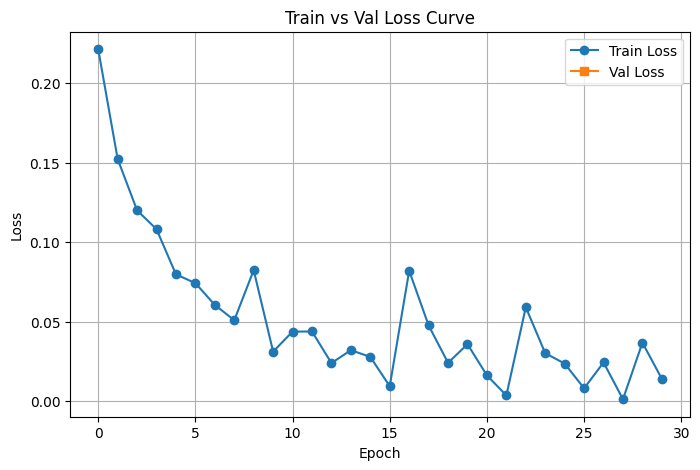

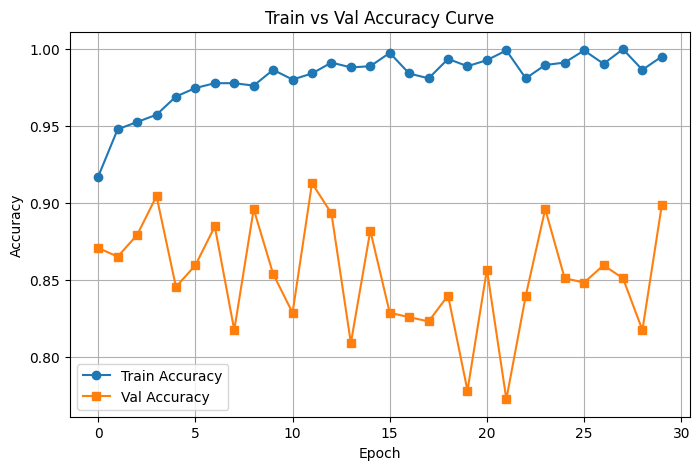


✅ Training finished successfully (from scratch).


In [ ]:
save_dir = "/content/AI model"
os.makedirs(save_dir, exist_ok=True)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

lst_train_all = filter_train_videos(lst_train_all, split_dict)

for epoch in range(curr_epoch, max_epoch):
    print(f"\n[Epoch {epoch+1}/{max_epoch}]")

    # Shuffle training data
    random.shuffle(lst_train_all)

    tsm_model.train()
    running_loss, running_acc, num_batches = 0.0, 0.0, 0
    current_clip_index = 0
    num_clips = len(lst_train_all)

    # --- Training loop ---
    while current_clip_index < num_clips:
        batch_clips, batch_labels = batch_generation(lst_train_all, current_clip_index, batch_size)
        current_clip_index += batch_size

        optimizer.zero_grad()
        outputs = tsm_model(batch_clips)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)
        acc = (preds == batch_labels).float().mean()

        running_loss += loss.item()
        running_acc += acc.item()
        num_batches += 1

        if num_batches % 10 == 0:
            print(f"  Batch {num_batches:03d}: Loss={loss.item():.4f}, Acc={acc.item():.4f}")

    # --- Epoch-level train metrics ---
    epoch_loss = running_loss / max(1, num_batches)
    epoch_acc = running_acc / max(1, num_batches)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    print(f"[Train] Epoch {epoch+1}: Loss={epoch_loss:.4f}, Acc={epoch_acc:.4f}")

    # --- Evaluate on train / val / test ---
    print("\nEvaluating training data...")
    train_eval_acc, train_eval_f1, train_eval_cm, train_report, _ = evaluate_tsm(tsm_model, train_df)
    print("📊 Train metrics:\n", train_report)

    print("Evaluating validation data...")
    val_eval_acc, val_eval_f1, val_eval_cm, val_report, _ = evaluate_tsm(tsm_model, val_df)
    val_accs.append(val_eval_acc)
    print("📊 Validation metrics:\n", val_report)

    print("Evaluating test data...")
    test_eval_acc, test_eval_f1, test_eval_cm, test_report, test_loss = evaluate_tsm(tsm_model, test_df)
    print(f"📊 Test Loss: {test_loss:.4f}")
    print("📊 Test metrics:\n", test_report)

    # --- Check overfitting gap ---
    check_overfit_gap(epoch_acc, val_eval_acc)

    # --- Save checkpoint ---
    checkpoint_path = os.path.join(save_dir, f"tsm_feature_epoch_{epoch}.pt")
    torch.save(tsm_model.state_dict(), checkpoint_path)
    print(f"[Checkpoint] Saved model → {checkpoint_path}")

# --- Plot curves ---
plot_loss(train_losses, val_losses)
plot_accuracy(train_accs, val_accs)

print("\n✅ Training finished successfully (from scratch).")

Checking leakage

In [ ]:
# ==========================================================
# 🔍 TEST FOR DATA LEAKAGE — Shuffle labels and retrain
# ==========================================================
import torch, os, random
import numpy as np
from sklearn.metrics import classification_report
from copy import deepcopy

# --- Copy & shuffle labels ---
shuffled_df = deepcopy(df)
shuffled_df['label'] = np.random.permutation(shuffled_df['label'].values)
print("🔀 Labels have been shuffled for leakage test!\n")
print(shuffled_df[['folder_name', 'label', 'train_val_test']])

# --- Prepare splits ---
train_df = shuffled_df[shuffled_df['train_val_test'] == 'train']
val_df   = shuffled_df[shuffled_df['train_val_test'] == 'val']
test_df  = shuffled_df[shuffled_df['train_val_test'] == 'test']

# --- Device & model setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_dir = "/content/AI_model_leak_test"
os.makedirs(save_dir, exist_ok=True)

tsm_model = TSMFeatureModel(feature_dim=2048, num_classes=2, n_segment=32).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tsm_model.parameters(), lr=1e-4, weight_decay=1e-5)

# --- Training config ---
max_epoch = 5     # chỉ cần vài epoch để test leakage
batch_size = 4
# lst_train_all = lst_violence_clips + lst_non_violence_clips  # dùng list gốc của bạn

train_losses, val_losses = [], []

for epoch in range(max_epoch):
    print(f"\n[Leakage Test Epoch {epoch+1}/{max_epoch}]")
    random.shuffle(lst_train_all)

    tsm_model.train()
    current_clip_index, running_loss, running_acc, num_batches = 0, 0.0, 0.0, 0

    while current_clip_index < len(lst_train_all):
        batch_clips, batch_labels = batch_generation(lst_train_all, current_clip_index, batch_size=batch_size)
        current_clip_index += batch_size

        optimizer.zero_grad()
        outputs = tsm_model(batch_clips)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)
        acc = (preds == batch_labels).float().mean()

        running_loss += loss.item()
        running_acc += acc.item()
        num_batches += 1

    epoch_loss = running_loss / max(1, num_batches)
    epoch_acc = running_acc / max(1, num_batches)
    print(f"[Train] Epoch {epoch+1}: Loss={epoch_loss:.4f}, Acc={epoch_acc:.4f}")

    # --- Evaluate on validation/test ---
    val_acc, val_f1, val_cm, val_report, _ = evaluate_tsm(tsm_model, val_df)
    test_acc, test_f1, test_cm, test_report, _ = evaluate_tsm(tsm_model, test_df)

    print("📊 Validation metrics:\n", val_report)
    print("📊 Test metrics:\n", test_report)
    print("------------------------------------------------------")

print("\n✅ Leakage check completed! If acc ≈ 0.5 → No leakage 😎")

🔀 Labels have been shuffled for leakage test!

                                           folder_name        label  \
0                                       0_1 man escape     Violence   
1                                 0_A girl is muckbang     Violence   
2                      100_2 wm fight on crossing line     Violence   
3    101_2 wm fight ouside a house, 1 fat and wear ...     Violence   
4                           102_2 wm fight slow motion     Violence   
..                                                 ...          ...   
311  97_2 wm fight next to a fence, 1 have headband...  NonViolence   
312              98_2 wm fight next to red brick house     Violence   
313              99_2 wm fight next to school's locket     Violence   
314  9_1 man in an orange shirt and 1 man in orange...     Violence   
315                            9_Badminton competition     Violence   

    train_val_test  
0              val  
1            train  
2              val  
3             te